<a href="https://colab.research.google.com/github/haddybhaiya/unsupervised-learning-classes/blob/main/cancer_detection_via_images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
path  = kagglehub.dataset_download('bhaveshmittal/melanoma-cancer-dataset')
print ('done')

100%|██████████| 79.4M/79.4M [00:00<00:00, 118MB/s]

Extracting files...


done


In [2]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense , Dropout , BatchNormalization,GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
# dataset directories

In [4]:
TRAIN_DIR = os.path.join(path,"train")
TEST_DIR = os.path.join(path,"test")


In [5]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

In [6]:
train_datagen = ImageDataGenerator(
    rescale = 1./255,
    rotation_range = 20,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True
)

test_datagen = ImageDataGenerator(rescale = 1./255)

#load Training data
train_generator = train_datagen.flow_from_directory(
    directory=TRAIN_DIR,
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = "binary"
)

Found 11879 images belonging to 2 classes.


In [7]:
test_generator = test_datagen.flow_from_directory(
    directory=TEST_DIR,
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = "binary"
)

Found 2000 images belonging to 2 classes.


In [8]:
print("class Mapping",train_generator.class_indices)

class Mapping {'Benign': 0, 'Malignant': 1}


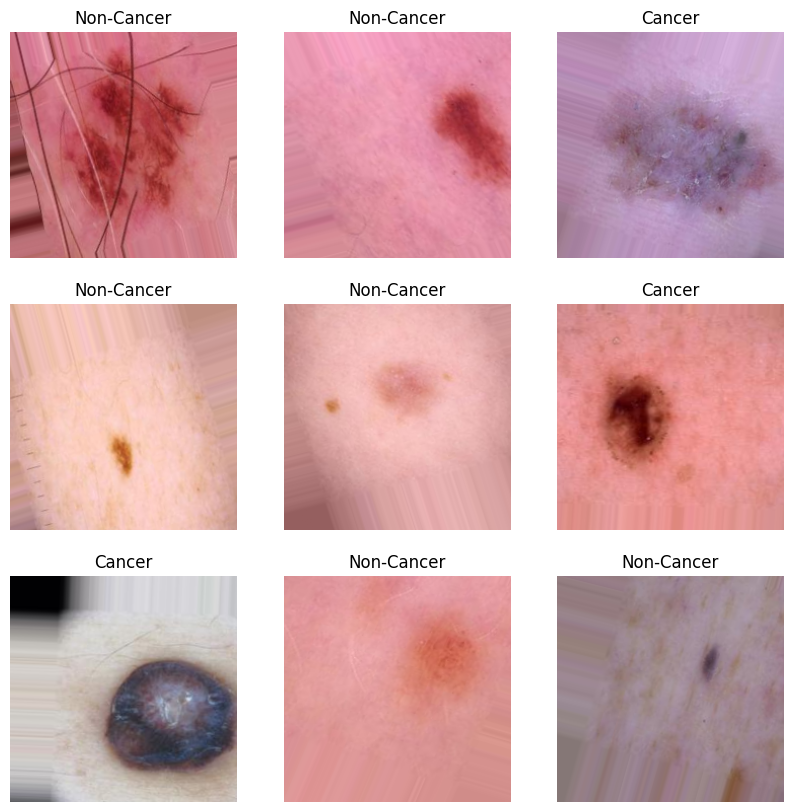

In [9]:
#display some smaple images
def plot_images(generator):
  images,labels = next(generator)
  plt.figure(figsize = (10,10))
  for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title("Cancer" if labels[i] == 1 else "Non-Cancer")
    plt.axis("off")
  plt.show()
plot_images(train_generator)

In [10]:
from tensorflow.keras import layers, models

#build the cnn model
model = models.Sequential([
    #1st layer
    layers.Conv2D(32,(3,3),activation = 'relu',input_shape = (224,224,3)),
    layers.MaxPooling2D((2,2)),

    #2nd layer
    layers.Conv2D(64,(3,3),activation = 'relu'),
    layers.MaxPooling2D((2,2)),

    #3rd Convolution Block
    layers.Conv2D(128,(3,3),activation = 'relu'),
    layers.MaxPooling2D((2,2)),

    #faltten layers
    layers.Flatten(),

    #FullyConnected layer
    layers.Dense(512,activation = 'relu'),
    layers.Dropout(0.5),
    layers.Dense(1,activation = 'sigmoid')

])
model.compile(optimizer = 'adam',loss = 'binary_crossentropy',metrics = ['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    44,302,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,396,609 (169.36 MB)

 Trainable params: 44,396,609 (169.36 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
early_stopping = EarlyStopping(
    monitor = 'val_loss', #early stopping to stop model training when ACCuracy not improving
    patience = 5,
    restore_best_weights = True,
    verbose = 1

)
lr_scheduler = ReduceLROnPlateau(
    monitor = 'val_loss',
    factor = 0.3,
    patience = 3, #reduce lr if no improvement after a 3 epochs
    min_lr = 1e-7,
    verbose = 1
)

history = model.fit(
    train_generator,
    steps_per_epoch = train_generator.samples // BATCH_SIZE,
    epochs= 10,
    validation_data = test_generator,
    validation_steps = test_generator.samples // BATCH_SIZE,
    callbacks = [early_stopping,lr_scheduler]

)


Epoch 1/10
371/371 ━━━━━━━━━━━━━━━━━━━━ 158s 404ms/step - accuracy: 0.7577 - loss: 0.5103 - val_accuracy: 0.8468 - val_loss: 0.4055 - learning_rate: 0.0010
Epoch 2/10
  1/371 ━━━━━━━━━━━━━━━━━━━━ 24s 65ms/step - accuracy: 0.9062 - loss: 0.3724

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


371/371 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9062 - loss: 0.3724 - val_accuracy: 0.8231 - val_loss: 0.3920 - learning_rate: 0.0010
Epoch 3/10
371/371 ━━━━━━━━━━━━━━━━━━━━ 145s 391ms/step - accuracy: 0.8135 - loss: 0.4113 - val_accuracy: 0.8014 - val_loss: 0.4236 - learning_rate: 0.0010
Epoch 4/10
371/371 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8438 - loss: 0.3491 - val_accuracy: 0.7772 - val_loss: 0.4616 - learning_rate: 0.0010
Epoch 5/10
371/371 ━━━━━━━━━━━━━━━━━━━━ 147s 397ms/step - accuracy: 0.8276 - loss: 0.3866 - val_accuracy: 0.8382 - val_loss: 0.3696 - learning_rate: 0.0010
Epoch 6/10
371/371 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8438 - loss: 0.3386 - val_accuracy: 0.8377 - val_loss: 0.3718 - learning_rate: 0.0010
Epoch 7/10
371/371 ━━━━━━━━━━━━━━━━━━━━ 146s 394ms/step - accuracy: 0.8304 - loss: 0.3729 - val_accuracy: 0.7883 - val_loss: 0.4448 - learning_rate: 0.0010
Epoch 8/10
  1/371 ━━━━━━━━━━━━━━━━━━━━ 25s 68ms/step - accuracy: 0.8750 - loss: 0.473

In [12]:
model.save("skin_cancer_cnn.h5")

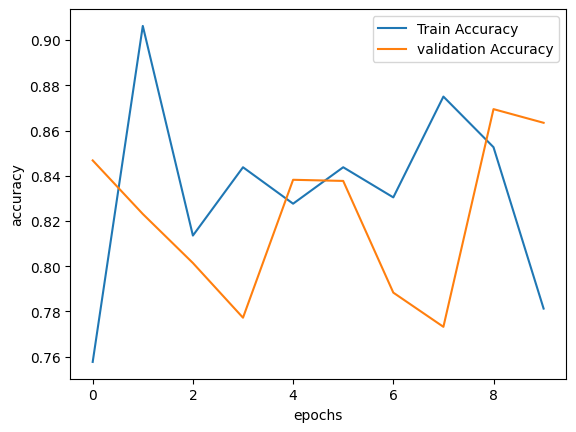

In [13]:
plt.plot(history.history['accuracy'],label = 'Train Accuracy')
plt.plot(history.history['val_accuracy'],label="validation Accuracy")
plt.xlabel("epochs")
plt.ylabel('accuracy')
plt.legend()
plt.show()

62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step
classification Report
              precision    recall  f1-score   support

           0       0.50      0.55      0.52      1000
           1       0.49      0.44      0.46       984

    accuracy                           0.49      1984
   macro avg       0.49      0.49      0.49      1984
weighted avg       0.49      0.49      0.49      1984



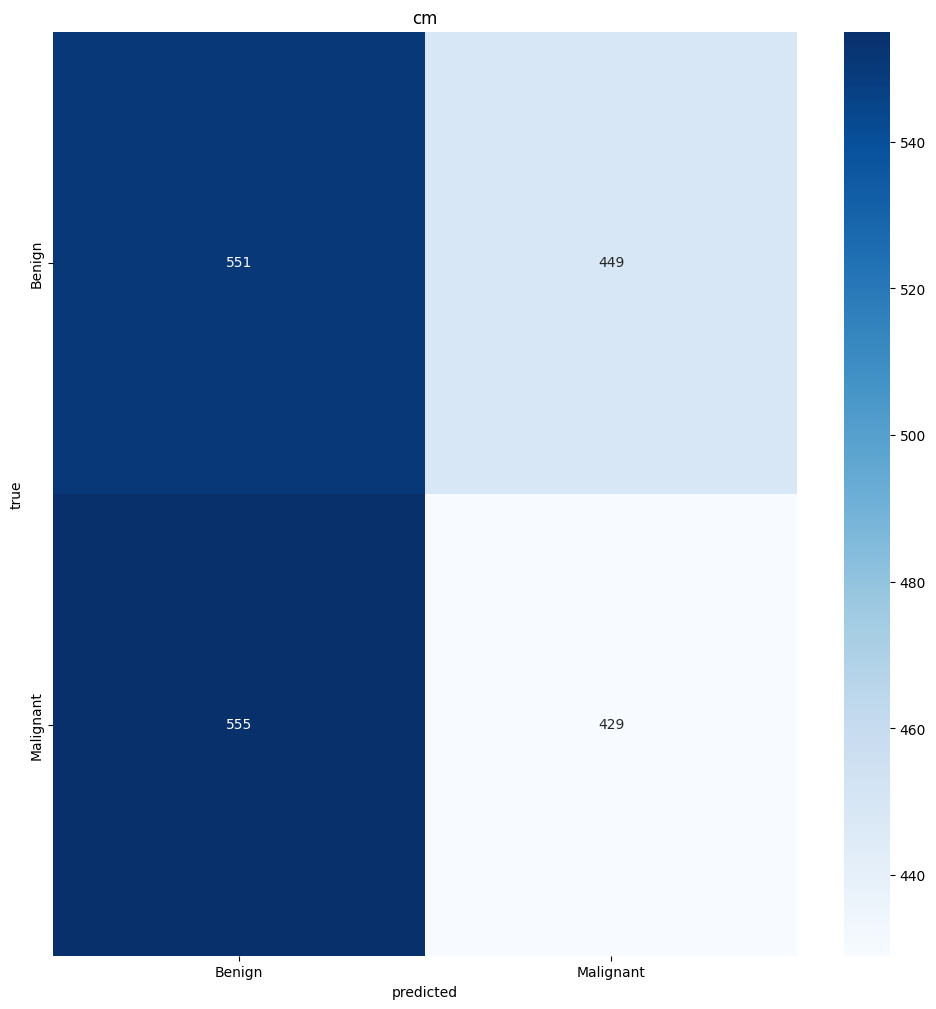

In [16]:
#evaluate model performance
test_pred = model.predict(test_generator,steps = test_generator.samples // BATCH_SIZE,verbose = 1)


test_pred_labels = (test_pred > 0.5).astype('int32')

test_true_labels = test_generator.classes[:len(test_pred_labels)]

print('classification Report')
print(classification_report(test_true_labels,test_pred_labels))

cm = confusion_matrix(test_true_labels,test_pred_labels)

plt.figure(figsize = (12,12))
sns.heatmap(cm,annot = True,fmt = 'd',cmap = 'Blues',xticklabels= train_generator.class_indices.keys(),yticklabels= train_generator.class_indices.keys())
plt.xlabel('predicted')
plt.ylabel('true')
plt.title('cm')

plt.show()